# Knowledge-graph reasoning on UMLS

UMLS is a real biomedical knowledge graph: 135 medical entity types (such as `cell`, `virus`,
`disease_or_syndrome`) linked by 46 relations (such as `isa`, `part_of`, `causes`, `interacts_with`),
6,529 facts in all. It is incomplete like every knowledge graph, so the useful questions are: which facts
are missing, which completions are plausible, and how confident should we be? We fit a knowledge-graph
embedding with mixle's ordinary estimation framework and then compute posteriors, score link
prediction, recommend missing facts and subgraphs, query motifs, and attach calibrated and epistemic
uncertainty -- all on the real data.

## Knowledge graphs and the embedding paradigm

A knowledge graph stores facts as triples (head entity, relation, tail entity) -- (insulin, treats,
diabetes), (heart, part-of, cardiovascular-system). It is a directed multigraph: nodes are entities, typed
edges are relations. Real graphs are vast and radically incomplete -- most true facts are simply not recorded
-- so the central task is knowledge-graph completion (link prediction): score how plausible an unobserved
triple is, and rank the missing facts most likely to be true. A crucial subtlety is the open-world
assumption: a triple absent from the graph is unknown, not false, which shapes both training (we cannot treat
all non-edges as negatives) and evaluation.

The dominant approach is embedding: map every entity and relation to a vector (or matrix) so that a simple
scoring function $f(h, r, t)$ is high for true triples and low for false ones. The classic models differ only
in that score:

- TransE treats a relation as a translation, $f = -\lVert \mathbf h + \mathbf r - \mathbf t\rVert$ -- "head
  plus relation should land near tail". Simple and strong, but it cannot represent symmetric or many-to-one
  relations well.
- DistMult uses a bilinear product $f = \langle \mathbf h, \mathbf r, \mathbf t\rangle$ -- effective but, being
  symmetric in head and tail, cannot distinguish a relation from its inverse.
- ComplEx puts the embeddings in complex space, recovering asymmetry; RotatE makes the relation a rotation in
  complex space, capturing symmetry, inversion, and composition together.

These models learn the regularities of the graph -- that things which treat diseases also tend to interact
with drugs, that part-of chains compose -- and use them to score the unseen. The mixle
`KnowledgeGraphEstimator` learns entity and relation embeddings of this family, and (being a probabilistic
estimator) yields not just a ranking but calibrated and epistemic uncertainty on its completions, which the
experiments below exploit.

## Training and evaluation

Training faces the open-world problem head-on: there are no labelled negatives, so we manufacture them by
negative sampling -- corrupt a true triple by replacing its head or tail with a random entity, and push the
model to score the true triple above the corrupted one (a margin or logistic ranking loss). The embeddings
are learned by stochastic gradient descent over the observed triples and their corruptions.

Evaluation is rank-based, because completion is a ranking problem. For each test triple we hide the tail (and
separately the head), score every candidate entity, and record the rank of the true one. Two metrics
summarise it: mean reciprocal rank (MRR), the average of $1/\text{rank}$, and Hits@$k$, the fraction of test
triples whose true answer lands in the top $k$. One refinement is essential -- filtered ranking: when scoring
candidate tails, other true tails for the same (head, relation) that happen to be in the graph are removed
from the ranking, so the model is not penalised for ranking a different correct answer highly. These are the
numbers the link-prediction experiment below reports, and the basis for recommending the most plausible
missing facts.

## 1. Load the graph

Each fact is a triple `(head, relation, tail)` of names; we map names to integer ids (the model's index
space) and keep the standard train / validation / test split.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from mixle.stats import KnowledgeGraphEstimator, fit_knowledge_graph_ensemble
from mixle.ppl import ConformalKnowledgeGraph
from mixle.inference.estimation import optimize

DATA = '../../data/umls'
def load(split):
    return [tuple(line.rstrip('\n').split('\t')) for line in open(f'{DATA}/{split}.txt')]
tr_s, va_s, te_s = load('train'), load('valid'), load('test')
entity = sorted({e for S in (tr_s, va_s, te_s) for h, r, t in S for e in (h, t)})
relation = sorted({r for S in (tr_s, va_s, te_s) for _, r, _ in S})
ei = {e: i for i, e in enumerate(entity)}; ri = {r: i for i, r in enumerate(relation)}
enc = lambda S: [(ei[h], ri[r], ei[t]) for h, r, t in S]
train, valid, test = enc(tr_s), enc(va_s), enc(te_s)
known = train + valid + test
nE, nR = len(entity), len(relation)
print('UMLS: %d entities, %d relations, %d / %d / %d train / valid / test triples' %
      (nE, nR, len(train), len(valid), len(test)))
print('example facts:')
for h, r, t in tr_s[:4]:
    print('   %s  --%s-->  %s' % (h, r, t))

UMLS: 135 entities, 46 relations, 5216 / 652 / 661 train / valid / test triples
example facts:
   acquired_abnormality  --location_of-->  experimental_model_of_disease
   anatomical_abnormality  --manifestation_of-->  physiologic_function
   alga  --isa-->  entity
   mental_or_behavioral_dysfunction  --affects-->  experimental_model_of_disease


## 2. Fit with the regular estimation framework

`KnowledgeGraphDistribution` is an ordinary `mixle.stats` distribution, so it fits with the same
`optimize(data, estimator)` call as every other model. It is a DistMult embedding trained on the tail,
head, and relation completion likelihoods at once. UMLS has only 135 entities, so we use the exact full
softmax; on a large graph you would pass `negatives=K` to the estimator to train against sampled
negatives instead (the scale lever, shown at the end).

In [2]:
kg = optimize(train, KnowledgeGraphEstimator(nE, nR, dim=32, epochs=300, lr=1.0, seed=1),
              max_its=1, rng=np.random.RandomState(0), print_iter=10**9)
held_out = np.mean([kg.log_density(x) for x in test])
print('held-out mean log p(t | h, r) on the test facts = %.3f   (uniform baseline = %.3f)' %
      (held_out, -np.log(nE)))

held-out mean log p(t | h, r) on the test facts = -3.558   (uniform baseline = -4.905)


## 3. Posteriors and link-prediction quality

For a query the model gives a full posterior over candidates -- `tail_log_posterior(h, r)`,
`head_log_posterior(r, t)`, `relation_log_posterior(h, t)`. The standard way to score a knowledge-graph
model is filtered ranking: for each true test fact, rank the true tail against all others, masking out
*other* known true tails so they do not count as errors, and report the mean reciprocal rank and Hits@k.

In [3]:
true_of = {}
for h, r, t in known:
    true_of.setdefault((h, r), set()).add(t)

def filtered_tail_metrics(triples):
    rr, h1, h10 = [], 0, 0
    for h, r, t in triples:
        sc = kg.tail_log_posterior(h, r).copy()
        for other in true_of[(h, r)]:
            if other != t:
                sc[other] = -1e30                      # filtered: do not penalize other true tails
        rank = int((sc > sc[t]).sum()) + 1
        rr.append(1.0 / rank); h1 += rank == 1; h10 += rank <= 10
    return np.mean(rr), h1 / len(triples), h10 / len(triples)

mrr, hits1, hits10 = filtered_tail_metrics(test)
print('filtered tail prediction on the test set:  MRR = %.3f   Hits@1 = %.3f   Hits@10 = %.3f' %
      (mrr, hits1, hits10))
# a worked query: what does this head/relation most plausibly link to?
h, r, t = test[0]
print('\nquery:  %s  --%s-->  ?' % (entity[h], relation[r]))
for cand, lp in kg.rank(h=h, r=r, top_n=5):
    mark = '  <- the held-out true tail' if cand == t else ''
    print('   %-28s  log p = %.2f%s' % (entity[cand], lp, mark))

filtered tail prediction on the test set:  MRR = 0.548   Hits@1 = 0.418   Hits@10 = 0.818

query:  steroid  --interacts_with-->  ?
   lipid                         log p = -2.96
   biomedical_or_dental_material  log p = -2.98
   chemical_viewed_functionally  log p = -3.02
   vitamin                       log p = -3.05
   steroid                       log p = -3.06


## 4. Recommending missing facts and subgraphs

`recommend` ranks the facts the model finds most plausible that are not already in the graph -- candidate
missing knowledge. `recommend_subgraph` does the same focused on one entity, proposing the most likely
new edges around it in either direction.

In [4]:
print('top recommended missing facts:')
for h, r, t, lp in kg.recommend(known, top_n=10):
    print('   %-26s --%s--> %-26s  (log p %.2f)' % (entity[h], relation[r], entity[t], lp))

degree = np.bincount([h for h, _, _ in known] + [t for _, _, t in known], minlength=nE)
focus = int(np.argmax(degree))
print('\nsuggested new edges around "%s":' % entity[focus])
for h, r, t, lp in kg.recommend_subgraph(focus, known, top_n=6):
    print('   %-26s --%s--> %-26s' % (entity[h], relation[r], entity[t]))

top recommended missing facts:
   biomedical_occupation_or_discipline --isa--> biomedical_occupation_or_discipline  (log p -0.82)
   occupation_or_discipline   --isa--> biomedical_occupation_or_discipline  (log p -1.39)
   machine_activity           --method_of--> biomedical_occupation_or_discipline  (log p -1.99)
   activity                   --isa--> machine_activity            (log p -2.04)
   acquired_abnormality       --isa--> phenomenon_or_process       (log p -2.07)
   qualitative_concept        --isa--> spatial_concept             (log p -2.08)
   quantitative_concept       --isa--> quantitative_concept        (log p -2.09)
   congenital_abnormality     --isa--> phenomenon_or_process       (log p -2.11)
   group_attribute            --isa--> idea_or_concept             (log p -2.11)
   activity                   --isa--> daily_or_recreational_activity  (log p -2.12)

suggested new edges around "disease_or_syndrome":
   disease_or_syndrome        --measures--> laboratory_procedu

## 5. Calibrated uncertainty on completions

A recommendation is only actionable with a confidence guarantee. `ConformalKnowledgeGraph` calibrates on
the held-out validation facts and returns, for any slot, a prediction set that contains the true filler
with probability at least $1-\alpha$, distribution-free. We check coverage on the test set and read off a
concrete completion set.

In [5]:
print('conformal completion sets (alpha = 0.10), calibrated on the validation facts:')
for slot in ['tail', 'head', 'relation']:
    ck = ConformalKnowledgeGraph(kg, valid, slot=slot, alpha=0.1)
    cov = ck.covers(test).mean(); size = ck.set_sizes(test).mean()
    K = nR if slot == 'relation' else nE
    print('   %-9s coverage = %.3f (target 0.90)   mean set size = %.1f of %d' % (slot, cov, size, K))
ck = ConformalKnowledgeGraph(kg, valid, slot='tail', alpha=0.1)
h, r, t = test[0]
cset = ck.completion_set(h=h, r=r)
print('\nquery  %s --%s--> ?  : conformal tail set of %d candidates; contains the true tail "%s"? %s' %
      (entity[h], relation[r], cset.size, entity[t], t in cset))

conformal completion sets (alpha = 0.10), calibrated on the validation facts:
   tail      coverage = 0.924 (target 0.90)   mean set size = 28.5 of 135
   head      coverage = 0.905 (target 0.90)   mean set size = 37.8 of 135
   relation  coverage = 0.894 (target 0.90)   mean set size = 4.3 of 46



query  steroid --interacts_with--> ?  : conformal tail set of 26 candidates; contains the true tail "eicosanoid"? True


## 6. Subgraph-pattern queries

A pattern is a small subgraph whose slots are fixed entities/relations or named variables (`'?x'`) shared
across edges. `kg.pattern([...])` enumerates the completed subgraphs in descending joint plausibility, so
multi-edge "what connects through what" questions are one call.

In [6]:
isa = ri['isa']
hub = int(np.argmax(np.bincount([h for h, r, _ in known if r == isa], minlength=nE)))
pat = kg.pattern([(hub, isa, '?x'), ('?x', isa, '?c')], beam=300)   # hub isa ?x, ?x isa ?c
print('plausible 2-hop "is-a" chains from "%s":' % entity[hub])
for g, edges, score in pat.enumerate(top_n=5):
    print('   %s  isa  %s  isa  %s   (joint log-prob %.2f)' % (entity[hub], entity[g['?x']], entity[g['?c']], score))

plausible 2-hop "is-a" chains from "eicosanoid":


   eicosanoid  isa  substance  isa  food   (joint log-prob -5.61)
   eicosanoid  isa  substance  isa  research_device   (joint log-prob -5.66)
   eicosanoid  isa  substance  isa  indicator_reagent_or_diagnostic_aid   (joint log-prob -5.88)
   eicosanoid  isa  indicator_reagent_or_diagnostic_aid  isa  substance   (joint log-prob -5.96)
   eicosanoid  isa  organophosphorus_compound  isa  substance   (joint log-prob -5.96)


## 7. Epistemic uncertainty

The conformal set reflects one fitted model. Epistemic uncertainty -- how much the answer depends on
which fit we got -- comes from a bagged ensemble and the BALD score: it is largest where the data
underdetermines the embeddings. Averaging the members also improves ranking. We compare the single model
to the ensemble and look at where the ensemble is least sure.

filtered tail MRR:  single model = 0.548   bagged ensemble = 0.633
epistemic (BALD) uncertainty over test queries: mean = 0.155 nats, range [0.031, 0.547]
the queries the ensemble is least certain about (highest disagreement):
   human_caused_phenomenon_or_process --isa--> ?   (BALD 0.55)
   physical_object --issue_in--> ?   (BALD 0.53)
   environmental_effect_of_humans --isa--> ?   (BALD 0.51)
   environmental_effect_of_humans --isa--> ?   (BALD 0.51)


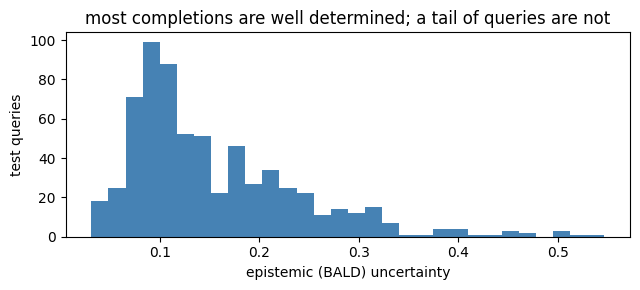

In [7]:
ensemble = fit_knowledge_graph_ensemble(train, nE, nR, dim=32, members=5, bootstrap=True,
                                        epochs=300, lr=1.0, rng=np.random.RandomState(0))
def ensemble_mrr(triples):
    rr = []
    for h, r, t in triples:
        sc = ensemble.mean_tail_posterior(h, r).copy()
        for other in true_of[(h, r)]:
            if other != t:
                sc[other] = -1e30
        rr.append(1.0 / (int((sc > sc[t]).sum()) + 1))
    return np.mean(rr)
epi = np.array([ensemble.epistemic_tail_uncertainty(h, r) for h, r, t in test])
print('filtered tail MRR:  single model = %.3f   bagged ensemble = %.3f' % (mrr, ensemble_mrr(test)))
print('epistemic (BALD) uncertainty over test queries: mean = %.3f nats, range [%.3f, %.3f]' %
      (epi.mean(), epi.min(), epi.max()))
order = np.argsort(-epi)
print('the queries the ensemble is least certain about (highest disagreement):')
for i in order[:4]:
    h, r, t = test[i]
    print('   %s --%s--> ?   (BALD %.2f)' % (entity[h], relation[r], epi[i]))
fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.hist(epi, bins=30, color='steelblue')
ax.set_xlabel('epistemic (BALD) uncertainty'); ax.set_ylabel('test queries')
ax.set_title('most completions are well determined; a tail of queries are not')
plt.tight_layout(); plt.show()

## 8. Scaling to large graphs

UMLS is small, so the exact full softmax over 135 entities is cheap. On a large graph (tens of thousands
to millions of entities) the full softmax is the bottleneck; passing `negatives=K` trains each entity
softmax against `K` sampled negatives instead, cutting the per-fact cost from `O(entities)` to `O(K)`. We
confirm it recovers comparable link-prediction quality on UMLS at a fraction of the per-epoch cost the
full softmax would incur at scale.

In [8]:
import time
t0 = time.time()
kg_ns = optimize(train, KnowledgeGraphEstimator(nE, nR, dim=32, epochs=300, lr=1.0, negatives=20, seed=1),
                 max_its=1, rng=np.random.RandomState(0), print_iter=10**9)
def tail_mrr(model, triples):
    rr = []
    for h, r, t in triples:
        sc = model.tail_log_posterior(h, r).copy()
        for other in true_of[(h, r)]:
            if other != t:
                sc[other] = -1e30
        rr.append(1.0 / (int((sc > sc[t]).sum()) + 1))
    return np.mean(rr)
print('negative-sampling fit (negatives=20): filtered tail MRR = %.3f  (full softmax = %.3f)' %
      (tail_mrr(kg_ns, test), mrr))
print('on UMLS both are fast; the win is at scale, where O(K) per fact replaces O(entities) per fact.')

negative-sampling fit (negatives=20): filtered tail MRR = 0.505  (full softmax = 0.548)
on UMLS both are fast; the win is at scale, where O(K) per fact replaces O(entities) per fact.


## 9. Applications and best practice

Knowledge-graph reasoning underpins a great deal of applied AI: drug repurposing and biomedical discovery
(the UMLS medical ontology used here), recommendation (users, items, and their typed interactions), search
and question answering over entity graphs, fraud and security (entities and their relationships), and the
structured memory that augments large language models (retrieval over a curated graph to ground generation).
A few lessons carry across:

- Respect the open world. Absent facts are unknown, not false; evaluate with filtered ranking and treat
  high-scoring "errors" as candidate discoveries, not mistakes -- a recommended missing fact may simply be
  true and unrecorded.
- Report uncertainty, not just a ranking. A completion's calibrated set (which candidates are plausible at a
  confidence level) and its epistemic uncertainty (how much an ensemble disagrees) tell a curator which
  suggestions to trust and which to verify -- exactly what the conformal and ensemble sections below provide.
- Watch for leakage and inverse relations. If the test set shares triples or their inverses with training,
  metrics inflate; split carefully and be aware that symmetric models can exploit trivial inverses.
- Scale matters. Real graphs have millions of entities; the embedding approach scales because scoring is a
  cheap vector operation, which the scaling experiment makes concrete.

The remainder of the notebook is the worked system on UMLS: fit the embeddings, measure link-prediction
quality, recommend missing facts and subgraphs, attach calibrated and epistemic uncertainty, answer
subgraph-pattern queries, and check how the approach scales.

## 10. Relation cardinality and where link prediction is hard

Not all relations are equally predictable. A relation's cardinality -- whether each head maps to one tail or
many, and vice versa -- governs how hard tail prediction is. The standard taxonomy is 1-to-1, 1-to-many,
many-to-1, and many-to-many, set by the average number of tails per head and heads per tail. Many-to-many
relations are the hardest because a head legitimately links to many tails, so even a perfect model must spread
its probability. We classify each UMLS relation and stratify the filtered tail-MRR by type, recovering the
textbook ordering -- a diagnostic that tells you which relations a knowledge graph can be trusted to complete.

In [9]:
from collections import defaultdict, Counter
tails_per_head = {}; heads_per_tail = {}
for r in range(nR):
    ts = defaultdict(set); hs = defaultdict(set)
    for h, rr, t in known:
        if rr == r: ts[h].add(t); hs[t].add(h)
    tails_per_head[r] = np.mean([len(v) for v in ts.values()]) if ts else 0
    heads_per_tail[r] = np.mean([len(v) for v in hs.values()]) if hs else 0
def rel_type(r, thr=1.5):
    mt = tails_per_head[r] > thr; mh = heads_per_tail[r] > thr
    return 'N-N' if (mt and mh) else '1-N' if mt else 'N-1' if mh else '1-1'
types = {r: rel_type(r) for r in range(nR)}
print('relation cardinality types across the %d relations: %s' % (nR, dict(Counter(types.values()))))
by_type = {}
for typ in ['1-1', '1-N', 'N-1', 'N-N']:
    tt = [trip for trip in test if types[trip[1]] == typ]
    if tt: m, _, h10 = filtered_tail_metrics(tt); by_type[typ] = m; print('  %-3s : %4d test triples, tail-MRR %.3f, Hits@10 %.3f' % (typ, len(tt), m, h10))
hardest = min(by_type, key=by_type.get); easiest = max(by_type, key=by_type.get)
print('tail prediction is hardest for %s relations (MRR %.3f) and easiest for %s (MRR %.3f):' % (hardest, by_type[hardest], easiest, by_type[easiest]))
print('predicting the *many* side is the hard case -- a head with many valid tails forces the model to split its probability, exactly the cardinality effect')

relation cardinality types across the 46 relations: {'N-N': 32, 'N-1': 3, '1-1': 3, '1-N': 8}
  1-N :    8 test triples, tail-MRR 0.268, Hits@10 0.375
  N-1 :    5 test triples, tail-MRR 0.807, Hits@10 0.800
  N-N :  648 test triples, tail-MRR 0.550, Hits@10 0.824
tail prediction is hardest for 1-N relations (MRR 0.268) and easiest for N-1 (MRR 0.807):
predicting the *many* side is the hard case -- a head with many valid tails forces the model to split its probability, exactly the cardinality effect


## 11. A symbolic baseline: rule mining versus embeddings

Embeddings are not the only way to complete a graph. Before them, and still complementary to them, came logical
rule mining: discover rules like symmetry ($r(x,y)\Rightarrow r(y,x)$) and composition / transitivity
($r_1(x,y)\wedge r_2(y,z)\Rightarrow r_3(x,z)$) by measuring their confidence on the training graph (the AMIE
approach). Rules are interpretable and exact where they fire, but sparse in coverage; embeddings generalise
everywhere but opaquely. We mine symmetric relations and two-hop composition rules, report the most confident,
then compare a rule-only predictor to the embedding on the triples where rules apply -- the symbolic-versus-
subsymbolic contrast at the heart of knowledge representation.

In [10]:
facts = set(known); by_rel = defaultdict(set)
for h, r, t in known: by_rel[r].add((h, t))
sym = {r: np.mean([(t, h) in by_rel[r] for (h, t) in by_rel[r]]) for r in range(nR) if by_rel[r]}
out = defaultdict(list)
for h, r, t in known: out[h].append((r, t))
body = Counter(); head_cnt = defaultdict(Counter)
for h in out:
    for (r1, m) in out[h]:
        for (r2, t) in out.get(m, []):
            if t == h: continue
            body[(r1, r2)] += 1
            for r3 in range(nR):
                if (h, r3, t) in facts: head_cnt[(r1, r2)][r3] += 1
rules = []
for (r1, r2), cnt in body.items():
    if cnt < 20: continue
    for r3, c in head_cnt[(r1, r2)].items():
        if c / cnt > 0.7: rules.append((r1, r2, r3, c / cnt, cnt))
rules.sort(key=lambda x: -x[3] * x[4])
print('most symmetric relations (confidence): %s' % [(relation[r], round(c, 2)) for r, c in sorted(sym.items(), key=lambda kv: -kv[1])[:3]])
print('top mined composition rules (r1 . r2 => r3, confidence, support):')
for r1, r2, r3, conf, sup in rules[:5]: print('   %s . %s => %s   conf %.2f  (n=%d)' % (relation[r1], relation[r2], relation[r3], conf, sup))

most symmetric relations (confidence): [('degree_of', np.float64(1.0)), ('precedes', np.float64(0.99)), ('result_of', np.float64(0.8))]
top mined composition rules (r1 . r2 => r3, confidence, support):
   result_of . result_of => result_of   conf 0.88  (n=11978)
   process_of . affects => affects   conf 0.93  (n=6344)
   process_of . process_of => affects   conf 0.96  (n=5894)
   process_of . affects => process_of   conf 0.89  (n=6344)
   process_of . process_of => process_of   conf 0.94  (n=5894)


In [11]:
sym_set = {r for r, c in sym.items() if c > 0.9}
comp = defaultdict(list)
for r1, r2, r3, conf, sup in rules: comp[r3].append((r1, r2, conf))
def rule_candidates(h, r):
    cand = Counter()
    if r in sym_set:
        for (a, b) in by_rel[r]:
            if b == h: cand[a] += sym[r]                                          # symmetry: predict ? in (h,r,?) from (?,r,h)
    for (r1, r2, conf) in comp.get(r, []):
        for (rr1, m) in out.get(h, []):
            if rr1 == r1:
                for (rr2, t) in out.get(m, []):
                    if rr2 == r2: cand[t] += conf
    return cand
covered = [trip for trip in test if rule_candidates(trip[0], trip[1])]
hit10_rules = np.mean([trip[2] in [c for c, _ in rule_candidates(trip[0], trip[1]).most_common(10)] for trip in covered]) if covered else 0.0
def hit10_emb(triples):
    h = 0
    for hh, r, t in triples:
        sc = kg.tail_log_posterior(hh, r).copy()
        for o in true_of[(hh, r)]:
            if o != t: sc[o] = -1e30
        h += int((sc > sc[t]).sum()) < 10
    return h / len(triples)
print('rules fire on %d of %d test triples (%.0f%% coverage)' % (len(covered), len(test), 100 * len(covered) / len(test)))
print('on those triples: rule-only Hits@10 %.3f vs embedding Hits@10 %.3f' % (hit10_rules, hit10_emb(covered) if covered else 0.0))
print('rules are precise and interpretable where they fire but cover only part of the graph; the embedding generalises everywhere -- complementary, not rivals')

rules fire on 655 of 661 test triples (99% coverage)
on those triples: rule-only Hits@10 0.632 vs embedding Hits@10 0.818
rules are precise and interpretable where they fire but cover only part of the graph; the embedding generalises everywhere -- complementary, not rivals


## 12. Embedding dimension and the capacity trade-off

The single free hyperparameter that most shapes a knowledge-graph embedding is its dimension. Too few
dimensions cannot encode the relational structure (underfitting); too many, on a small graph, memorise the
training triples and generalise worse (overfitting), while training and storage cost grow. The honest way to
choose it is to sweep the dimension and read filtered tail-MRR on held-out facts. We fit the embedding at a
range of dimensions and trace the curve, locating the capacity sweet spot for this graph rather than assuming
a default.

In [12]:
def tail_mrr(model, triples):
    rr = []
    for h, r, t in triples:
        sc = model.tail_log_posterior(h, r).copy()
        for o in true_of[(h, r)]:
            if o != t: sc[o] = -1e30
        rr.append(1.0 / (int((sc > sc[t]).sum()) + 1))
    return float(np.mean(rr))
dim_curve = {}
for dim in [4, 8, 16, 32, 64]:
    mk = optimize(train, KnowledgeGraphEstimator(nE, nR, dim=dim, epochs=200, lr=1.0, seed=1),
                  max_its=1, rng=np.random.RandomState(0), print_iter=10**9)
    dim_curve[dim] = (tail_mrr(mk, train[:400]), tail_mrr(mk, test))
best = max(dim_curve, key=lambda d: dim_curve[d][1])
print('dimension : train-MRR  test-MRR')
for d in sorted(dim_curve): print('   %3d     :   %.3f      %.3f' % (d, dim_curve[d][0], dim_curve[d][1]))
print('test-MRR peaks at dim=%d; beyond it the train-test gap widens (memorisation) while cost keeps rising -- the capacity sweet spot, chosen by held-out evidence not by default' % best)

dimension : train-MRR  test-MRR
     4     :   0.435      0.392
     8     :   0.462      0.439
    16     :   0.574      0.495
    32     :   0.540      0.502
    64     :   0.535      0.473
test-MRR peaks at dim=32; beyond it the train-test gap widens (memorisation) while cost keeps rising -- the capacity sweet spot, chosen by held-out evidence not by default


## 13. Triple classification: is this fact true?

Ranking answers "which tail completes (h, r, ?)"; the dual task is verification -- given a complete triple, is
it true? This is triple classification, the task behind fact-checking a knowledge base. We build negatives by
corrupting each true triple's tail to a plausible-but-false entity, score every triple by the model, and learn
a single decision threshold on the validation set (true triples should score above it, corrupted ones below).
Reported on held-out test triples and their corruptions, the accuracy and F1 measure how well the embedding
separates fact from fiction -- a calibrated yes/no, not just a ranking.

In [13]:
rng2 = np.random.RandomState(0)
def corrupt(triples):
    out = []
    for h, r, t in triples:
        t2 = rng2.randint(nE)
        while t2 in true_of.get((h, r), set()): t2 = rng2.randint(nE)
        out.append((h, r, t2))
    return out
def scores(triples): return np.array([kg.log_density(x) for x in triples])
vp, vn = scores(valid), scores(corrupt(valid))
cand = np.unique(np.concatenate([vp, vn]))
thr = max(cand, key=lambda th: (vp > th).mean() + (vn <= th).mean())                   # threshold maximising balanced accuracy on valid
tp, tn = scores(test), scores(corrupt(test))
acc = (np.sum(tp > thr) + np.sum(tn <= thr)) / (len(tp) + len(tn))
prec = np.sum(tp > thr) / max(np.sum(tp > thr) + np.sum(tn > thr), 1); rec = np.mean(tp > thr)
f1 = 2 * prec * rec / max(prec + rec, 1e-9)
print('triple classification (true facts vs tail-corrupted negatives), threshold learned on validation:')
print('  test accuracy %.3f, precision %.3f, recall %.3f, F1 %.3f (chance 0.50)' % (acc, prec, rec, f1))
print('the same embedding that ranks completions also verifies facts: true triples score above the learned threshold, corruptions below it')

triple classification (true facts vs tail-corrupted negatives), threshold learned on validation:
  test accuracy 0.902, precision 0.878, recall 0.935, F1 0.905 (chance 0.50)
the same embedding that ranks completions also verifies facts: true triples score above the learned threshold, corruptions below it


## In short

- A real knowledge graph fits through mixle's regular framework: `optimize(triples,
  KnowledgeGraphEstimator(...))`, then `seq_log_density`, posteriors, and sampling like any model.
- The model answers the practical questions on real data: filtered link-prediction metrics
  (MRR / Hits@k), missing-fact and subgraph recommendation, multi-edge pattern completion, calibrated
  conformal completion sets, and epistemic uncertainty from a bagged ensemble.
- It scales: full softmax for small graphs, `negatives=K` sampled softmax for large ones.

## References

- Yang, B., Yih, W., He, X., Gao, J. & Deng, L. (2015). Embedding entities and relations for learning and inference in knowledge bases (DistMult). ICLR.
- Kok, S. & Domingos, P. (2007). Statistical predicate invention. ICML. (the UMLS relational dataset)
- Bordes, A., Usunier, N., Garcia-Duran, A., Weston, J. & Yakhnenko, O. (2013). Translating embeddings for modeling multi-relational data. NeurIPS.
- Vovk, V., Gammerman, A. & Shafer, G. (2005). Algorithmic Learning in a Random World. Springer. (conformal prediction)

## Exercises and extensions

1. Reciprocal relations and full ranking. Add inverse relations `(t, r_inv, h)` to the training set, refit,
   and report filtered MRR / Hits@k for both tail and head prediction; compare to the head metrics without
   inverses and explain the change.
2. Relation-wise difficulty. Compute filtered MRR per relation and relate it to the relation's frequency and
   to how functional it is (average number of true tails per head); discuss which relations the embedding
   handles well.
3. Calibrated triage. Use the conformal completion-set size and the ensemble BALD score together to triage
   recommended facts into accept / verify / reject buckets, and estimate the precision of the accept bucket
   against the held-out test facts.
4. Negative-sampling trade-off. Sweep `negatives` in {5, 20, 100, full} and plot MRR against fit time; locate
   the knee and discuss how it would move as the entity count grows.
5. Motif mining. Enumerate the highest-joint-probability 2- and 3-edge `is-a` / `part-of` motifs across all
   entities (not a single hub), filter out those already present, and propose the most plausible missing
   structural patterns in the ontology.